<a href="https://colab.research.google.com/github/VJen1522/hello-world-and-beyond/blob/main/HW_TextCustomerInsights_JenkinsVeronica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction & Reasoning:

---


I made a slight change to the meal-subscription business plan as to keep with my previous data set for Alexa voice commands.

---
This analysis treats the mteb/amazon_massive_intent dataset (real subscriber voice-assistant commands) as interaction logs for a voice-assistant subscription company. Each utterance represents a real subscriber interaction; intent labels (provided by the dataset) stand in for the "star rating" ground-truth signal used in the original example.

In [1]:

# Install required packages
!pip install -q bertopic datasets sentence-transformers umap-learn hdbscan transformers accelerate torch pandas numpy matplotlib scikit-learn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.2 MB/s eta 0:00:00


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, AutoConfig
import torch
import warnings
from copy import deepcopy
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.11.0+cu128
CUDA available: True


##Resuming from Checkpoint
###Business Goal
Continue the analysis exactly where it previously stopped, without re‑running any of the expensive computational step, ensuring a smooth, efficient workflow even in a fresh runtime.

###What We’re Doing
We reload all previously saved artifacts from Google Drive back into memory, including:

- Command embeddings

- UMAP‑reduced vectors

- Cleaned subscriber utterances

- Intent labels

- Cluster assignments

The embedding model itself is reloaded separately. This is a lightweight operation, and only its outputs (not the model object) were saved during the checkpoint.

###Why This Matters
This single cell replaces Sections 1 through 6 when restarting in a new session. Free‑tier cloud environments can disconnect unpredictably, and without a checkpoint, we would need to re‑run ~10–15 minutes of embedding and clustering work.

Resumability is a core principle of real‑world data science pipelines — they’re designed to withstand interruptions, protect progress, and keep analysis moving without unnecessary recomputation.

In [4]:
# Resume from checkpoint instead of re-running Sections 1-6
from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = "/content/drive/MyDrive/BANA6370_Lab3"

import numpy as np
import pickle

embeddings = np.load(f"{DRIVE_FOLDER}/embeddings.npy")
reduced_embeddings_5d = np.load(f"{DRIVE_FOLDER}/reduced_embeddings_5d.npy")

with open(f"{DRIVE_FOLDER}/checkpoint_section6.pkl", "rb") as f:
    state = pickle.load(f)

texts = state["texts"]
ratings = state["ratings"]
indices = state["indices"]
clusters = state["clusters"]

print(f"Resumed: {len(texts):,} texts, {embeddings.shape} embeddings, {len(set(clusters))-1} clusters")

Mounted at /content/drive
Resumed: 9,544 texts, (9544, 384) embeddings, 45 clusters


---
# 1. Load Data

## Business Goal
Load voice-command data to understand the volume, distribution, and behavioral patterns behind how subscribers interact with a voice-driven service.

## What We're Doing
- Loading the `mteb/amazon_massive_intent` dataset from Hugging Face
- Extracting command text and intent labels
- Creating indices for traceability across the pipeline
- Sampling a manageable subset for analysis (to ensure reasonable compute time)

## Why This Matters
Understand how subscribers use voice commands helps us:
- Scope the analysis around usage patterns
- Confirm balanced representation across satisfaction tiers and subscription states
- Plan computational resources for downstream modeling and experimentation

## Business Translation
Each command represents subscriber interaction with a voice assistant. Unlike a review collection with star ratings, this dataset gives us intent labels — a human-annotated ground truth for what the subscriber was trying to accomplish (e.g., alarm_set, play_music, weather_query). We'll use these labels the way the original example used star ratings: as an independent signal to sanity-check whether our unsupervised clusters correspond to real, coherent subscriber intents.

In [5]:
# Load the amazon_massive_intent dataset from Hugging Face

from datasets import load_dataset

# dataset = load_dataset("amazon_massive_intent")["train"]
dataset = load_dataset("mteb/amazon_massive_intent", "en", split="train")

# Extract the relevant fields
texts = dataset["text"][:10000]  # Sample first 10,000 commands for manageable computation
labels = dataset["label"][:10000]

# Create indices for traceability
indices = list(range(len(texts)))

# No star ratings exist in this dataset -- we reuse the `ratings` variable name
# to hold intent labels, so later cells built for the star-rating format still work.
ratings = labels

print(f"\n{'='*60}")
print(f"DATASET SIZE")
print(f"{'='*60}")
print(f"Total commands loaded: {len(texts):,}")
print(f"Total unique intents: {len(set(ratings))}")
print(f"\nIntent distribution:")
rating_dist = pd.Series(ratings).value_counts().sort_index()
for rating, count in rating_dist.items():
    print(f"  {rating}: {count:,} commands ({count/len(ratings)*100:.1f}%)")

README.md:   0%|          | 0.00/29.5k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

train/en.json.gz: reconstructing file:   0%|          |  0.00B /  187kB            

...

validation/en.json.gz: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]


DATASET SIZE
Total commands loaded: 10,000
Total unique intents: 59

Intent distribution:
  alarm_query: 130 commands (1.3%)
  alarm_remove: 78 commands (0.8%)
  alarm_set: 182 commands (1.8%)
  audio_volume_down: 52 commands (0.5%)
  audio_volume_mute: 110 commands (1.1%)
  audio_volume_other: 18 commands (0.2%)
  audio_volume_up: 110 commands (1.1%)
  calendar_query: 563 commands (5.6%)
  calendar_remove: 312 commands (3.1%)
  calendar_set: 808 commands (8.1%)
  cooking_query: 4 commands (0.0%)
  cooking_recipe: 207 commands (2.1%)
  datetime_convert: 52 commands (0.5%)
  datetime_query: 350 commands (3.5%)
  email_query: 2 commands (0.0%)
  email_querycontact: 1 commands (0.0%)
  email_sendemail: 4 commands (0.0%)
  general_greet: 25 commands (0.2%)
  general_joke: 72 commands (0.7%)
  general_quirky: 531 commands (5.3%)
  iot_cleaning: 93 commands (0.9%)
  iot_coffee: 124 commands (1.2%)
  iot_hue_lightchange: 125 commands (1.2%)
  iot_hue_lightdim: 76 commands (0.8%)
  iot_hue_li

In [6]:
# Display preview of sample records
print(f"\n{'='*60}")
print(f"SAMPLE RECORDS")
print(f"{'='*60}\n")

for i in range(5):
    print(f"Command {i+1}:")
    print(f"  Intent: {ratings[i]}")
    print(f"  Text: {texts[i][:200]}...")
    print()


SAMPLE RECORDS

Command 1:
  Intent: alarm_set
  Text: wake me up at nine am on friday...

Command 2:
  Intent: alarm_set
  Text: set an alarm for two hours from now...

Command 3:
  Intent: audio_volume_mute
  Text: olly quiet...

Command 4:
  Intent: audio_volume_mute
  Text: stop...

Command 5:
  Intent: audio_volume_mute
  Text: olly pause for ten seconds...



---
# 2. Preprocess Text

## Business Goal
Prepare subscriber voice‑command data so the models receive clean, reliable input while preserving the authentic phrasing subscribers use when interacting with a service.

## What We're Doing
- Analyzing voice‑command character length to establish a defensible threshold for low‑information commands
- Removing commands that fall into the bottom 5th percentile of length (min_length = 13), which typically represent accidental triggers or incomplete requests
- Stripping extra whitespace and formatting
- Keeping preprocessing **lightweight, transparent, and defensible**

## Why This Matters
- **Too little preprocessing:** Fragmented commands can blur intent and produce unstable clusters
- **Too much preprocessing:** Risk of losing natural language cues subscribers rely on
- Our approach: Remove obvious low-quality commands while preserving subscriber voice and intent structure

## Decision Rationale
We avoid heavy preprocessing (stemming, lemmatization, stop-word removal) because:
1. Modern embedding models handle these variations linguistic variation and morphology
2. Preserving subscriber phrasing improves interpretability and insight
3. Phrases like "stop" or "don't" matter, however on thier own provide no actionable intent. Removing them entirely would distort meaning, but over-procssing would strip away the nuance that help us understand subscriber friction points.

In [7]:
# Quick check: what's the real character-length distribution?
lengths = [len(t) for t in texts]
print(f"Min: {min(lengths)}, Max: {max(lengths)}")
print(f"Mean: {sum(lengths)/len(lengths):.1f}")
print(f"5th percentile: {pd.Series(lengths).quantile(0.05):.0f}")
print(f"25th percentile: {pd.Series(lengths).quantile(0.25):.0f}")
print(f"Median: {pd.Series(lengths).quantile(0.50):.0f}")

Min: 2, Max: 189
Mean: 34.5
5th percentile: 13
25th percentile: 23
Median: 32


In [8]:
# Store original count
original_count = len(texts)

# Basic cleanup: remove extremely short reviews and strip whitespace
min_length = 13  # Minimum character threshold

# Filter and clean
clean_texts = []
clean_ratings = []
clean_indices = []

for i, text in enumerate(texts):
    # Strip whitespace
    cleaned = text.strip()

    # Keep only if meets minimum length
    if len(cleaned) >= min_length:
        clean_texts.append(cleaned)
        clean_ratings.append(ratings[i])
        clean_indices.append(indices[i])

# Update our working variables
texts = clean_texts
ratings = clean_ratings
indices = clean_indices

print(f"{'='*60}")
print(f"PREPROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Records before filtering: {original_count:,}")
print(f"Records after filtering:  {len(texts):,}")
print(f"Records removed:          {original_count - len(texts):,} ({(original_count - len(texts))/original_count*100:.1f}%)")
print(f"\nFiltering criterion: Minimum {min_length} characters")

PREPROCESSING SUMMARY
Records before filtering: 10,000
Records after filtering:  9,544
Records removed:          456 (4.6%)

Filtering criterion: Minimum 13 characters


---
# 3. Embedding Documents

## Business Goal
Transform subscriber voice commands text into numerical representations that capture semantic meaning, enabling us to analyze intent patterns across diverse phrasing styles.

## What We're Doing
Using a **SentenceTransformer** model (`thenlper/gte-small`) to create embeddings:
- Each command becomes a 384-dimensional vector
- Commands with similar intent have similar vectors
- This allows us to mathematically cluster, compare, and analyze subscriber behavior

## Why This Matters for Business
Traditional keyword matching would treat "turn off the lights" and "shut the lamp off" as completely different requests. Embeddings understand these phrases have the same underlying intent, allowing us to:
- Group similar commands even when subscribers use different phrases
- Discover reoccurring requst patterns that keyword searches would miss
- Quantify how closely subscriber language aligns with underlying intent

This is especially important in a subscription voice‑service environment where subscribers express the same action in dozens of ways depending on context, device, and personal speaking style.

## Technical Note
We intentionally use a smaller model (384 dimensions) to balance speed, cost, and quality. Larger models exist, but they significantly increase compute time without providing proportionate gains for this stage of analysis.

In [9]:
# Show before/after examples
print(f"\n{'='*60}")
print(f"BEFORE/AFTER EXAMPLES")
print(f"{'='*60}\n")

# Get original dataset for comparison

original_dataset = load_dataset(
    "mteb/amazon_massive_intent", "en",
    split="train"
)

# Show two examples
for i in [100, 102]:
    print(f"Example {i+1}:")
    print(f"  BEFORE: '{original_dataset['text'][i][:150]}'")
    print(f"  AFTER:  '{texts[i][:150]}'")
    print(f"  Length: {len(original_dataset['text'][i])} → {len(texts[i])} characters")
    print()


BEFORE/AFTER EXAMPLES



Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Example 101:
  BEFORE: 'this song was very good'
  AFTER:  'reduce the brightness'
  Length: 23 → 21 characters

Example 103:
  BEFORE: 'enable shuffle'
  AFTER:  'dim the lights'
  Length: 14 → 14 characters



In [10]:
# Load the sentence embedding model
print("Loading embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Create embeddings for all commands
print(f"Generating embeddings for {len(texts):,} commands...")
print("(This may take a few minutes...)")
embeddings = embedding_model.encode(texts, show_progress_bar=True)

# Report dimensions
print(f"\n{'='*60}")
print(f"EMBEDDING RESULTS")
print(f"{'='*60}")
print(f"Embedding shape: {embeddings.shape}")
print(f"  - Number of commands: {embeddings.shape[0]:,}")
print(f"  - Dimensions per command: {embeddings.shape[1]}")
print(f"  - Total parameters: {embeddings.shape[0] * embeddings.shape[1]:,}")
print(f"\nEach command is now represented as a {embeddings.shape[1]}-dimensional vector.")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings for 9,544 commands...
(This may take a few minutes...)


Batches:   0%|          | 0/299 [00:00<?, ?it/s]


EMBEDDING RESULTS
Embedding shape: (9544, 384)
  - Number of commands: 9,544
  - Dimensions per command: 384
  - Total parameters: 3,664,896

Each command is now represented as a 384-dimensional vector.


---
# 4. Reduce Dimensionality with UMAP

## Business Goal
Condense the 384‑dimensional command embeddings into a compact 5‑dimensional space so clustering becomes efficient, stable, and interpretable.

## What We're Doing
Using **UMAP** (Uniform Manifold Approximation and Projection):
- Reduces 384 dimensions → 5 dimensions
- Preserves the "neighborhood" structure (similar commands stay close)
- Makes clustering computationally feasible

## Why This Matters
**The Challenge:** High‑dimensional spaces make clustering unreliable.Distance metrics break down, noise dominates, and meaningful patterns become harder to detect.

**The Solution:** UMAP reduces dimensions while maintaining the relationships between commands. It effectively builds a simplified “map” of subscriber behavior where similar voice‑command points cluster naturally near one another.

## Business Analogy
Imagine subscriber command behavior described as hundreds of attributes. UMAP identifies the five most informative “summary dimensions” that capture the essential patterns, making it easier to spot meaningful groups—like recurring troubleshooting commands, upgrade requests, or content‑playback behaviors.

## Parameters Explained
- `n_components=5`: Reduce to 5 dimensions (enough for clustering, not too many)
- `metric='cosine'`: Measure similarity based on vector direction (good for text)
- `random_state=42`: Ensures reproducible results

In [11]:
# Create UMAP model for dimensionality reduction to 5D
print("We reduce the input embeddings from 384 dimenions to 5 dimenions for clustering:")
umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# Fit and transform the embeddings
reduced_embeddings_5d = umap_model.fit_transform(embeddings)

print(f"\n{'='*60}")
print(f"DIMENSIONALITY REDUCTION RESULTS")
print(f"{'='*60}")
print(f"Original embedding shape: {embeddings.shape}")
print(f"Reduced embedding shape:  {reduced_embeddings_5d.shape}")
print(f"Compression ratio:        {embeddings.shape[1]/reduced_embeddings_5d.shape[1]:.1f}x")
print(f"\nReduction: {embeddings.shape[1]} dimensions → {reduced_embeddings_5d.shape[1]} dimensions")

We reduce the input embeddings from 384 dimenions to 5 dimenions for clustering:

DIMENSIONALITY REDUCTION RESULTS
Original embedding shape: (9544, 384)
Reduced embedding shape:  (9544, 5)
Compression ratio:        76.8x

Reduction: 384 dimensions → 5 dimensions


---
# 5. Cluster Reduced Embeddings with HDBSCAN

## Business Goal
Automatically uncover natural groupings in subscriber voice‑command behavior without pre‑defining how many types of requests exist

## What We're Doing
We use HDBSCAN (Hierarchical Density‑Based Spatial Clustering) on the 5‑dimensional UMAP‑reduced embeddings to identify meaningful clusters of customer commands:

- Automatically determines the number of clusters based on the data
- Flags “outlier” commands that don’t fit any clear pattern
- Groups commands based on density—how tightly similar requests cluster together

## Why HDBSCAN for Business Analytics
Unlike K‑Means, which forces every command into a fixed number of clusters, HDBSCAN:

- Discovers clusters organically from subscriber behavior
- Identifies noise/outliers (labeled as -1)
- Handles clusters of different sizes and shapes
- Avoids forcing ambiguous or incomplete commands into a group

This flexibility is crucial for a voice‑subscription service, where customer phrasing varies widely and some commands may be accidental triggers, device‑specific, or too vague to classify.

## Parameters Explained
- `min_cluster_size=50`: Ensures each cluster represents a meaningful pattern of at least 50 commands
- `metric='euclidean'`: Standard distance measure in reduced 5-demensional UMAP space
- `cluster_selection_method='eom'`: Extracts stable, well-separated clusters that reflect customer behavior

## Interpreting Results
- **Cluster 0, 1, 2, ...**: Distinct themes in subscriber voice‑command behavior (e.g., playback requests, troubleshooting, account management)
- **Cluster -1**: Outliers: commands that don’t fit any clear pattern, often representing noise, accidental triggers, or highly unique phrasing

In [12]:
# Create and fit HDBSCAN model
print("Clustering commands using HDBSCAN...")
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric='euclidean',
    cluster_selection_method='eom'
).fit(reduced_embeddings_5d)

# Extract cluster labels
clusters = hdbscan_model.labels_

# Calculate statistics
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_outliers = list(clusters).count(-1)

print(f"\n{'='*60}")
print(f"CLUSTERING RESULTS")
print(f"{'='*60}")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers:       {n_outliers:,} ({n_outliers/len(clusters)*100:.1f}%)")
print(f"Total commands:            {len(clusters):,}")

Clustering commands using HDBSCAN...

CLUSTERING RESULTS
Number of clusters found: 45
Number of outliers:       1,684 (17.6%)
Total commands:            9,544


In [13]:
# Create cluster size table
cluster_sizes = pd.Series(clusters).value_counts().sort_index()

# Separate outliers from clusters
cluster_sizes_df = pd.DataFrame({
    'Cluster ID': cluster_sizes.index,
    'Size': cluster_sizes.values,
    'Percentage': (cluster_sizes.values / len(clusters) * 100).round(1)
})

# Mark outliers
cluster_sizes_df['Type'] = cluster_sizes_df['Cluster ID'].apply(
    lambda x: 'Outliers' if x == -1 else 'Cluster'
)

# Sort by size (excluding outliers) and show top 10 clusters
top_clusters = cluster_sizes_df[cluster_sizes_df['Cluster ID'] != -1].nlargest(10, 'Size')

print(f"\n{'='*60}")
print(f"TOP 10 CLUSTERS BY SIZE")
print(f"{'='*60}\n")
print(top_clusters.to_string(index=False))

# Show outlier stats separately
if -1 in clusters:
    outlier_row = cluster_sizes_df[cluster_sizes_df['Cluster ID'] == -1]
    print(f"\n{'='*60}")
    print(f"OUTLIERS")
    print(f"{'='*60}\n")
    print(outlier_row.to_string(index=False))


TOP 10 CLUSTERS BY SIZE

 Cluster ID  Size  Percentage    Type
         36   713         7.5 Cluster
          7   500         5.2 Cluster
          2   462         4.8 Cluster
         18   375         3.9 Cluster
         40   359         3.8 Cluster
         34   300         3.1 Cluster
         13   269         2.8 Cluster
          0   239         2.5 Cluster
          5   233         2.4 Cluster
         25   210         2.2 Cluster

OUTLIERS

 Cluster ID  Size  Percentage     Type
         -1  1684        17.6 Outliers


---
# 6. Inspect Clusters

## Business Goal
Manually review subscriber voice‑commands within each cluster to understand the real themes emerging from customer behavior.

## What We're Doing
Commands from three representative groups:
1. **One large cluster** - represents a major, recurring subscriber behavior pattern
2. **One medium cluster** - captures a mid-sized but meaningful theme
3. **The outlier group (-1)** - commands that don’t fit any clear pattern, often accidental triggers, vague phrasing, or highly unique requests

## Why This Matters
Numbers and algorithms are useful, but leadership needs to see **actual subscriber language** to:
- Validate that clusters align with real business-relevant behaviors
- Understand the specific actions, frustrations, or requests subscribers are expressing
- Identify actionable phrasing for product improvements, communication strategies, and design

## What to Look For
- **Coherent themes**: Do commands in a cluster revolve around the same topic (e.g., playback, troubleshooting, account management)?
- **Quality issues**: Are unrelated commands being grouped together, signaling a need to adjust parameters or preprocessing?
- **Surprise insights**: Any unexpected patterns like emerging device issues, new phrasing trends, or subscription related friction points?

In [14]:
# Get the largest non-outlier cluster
largest_cluster = cluster_sizes_df[cluster_sizes_df['Cluster ID'] != -1].iloc[29]['Cluster ID']

print(f"{'='*70}")
print(f"LARGE CLUSTER INSPECTION: Cluster {largest_cluster}")
print(f"{'='*70}")
print(f"Cluster size: {cluster_sizes[largest_cluster]:,} commands\n")

# Get indices of reviews in this cluster
cluster_indices = np.where(clusters == largest_cluster)[0]

# Show first 5 reviews
for i, idx in enumerate(cluster_indices[:5]):
    print(f"Command {i+1} : {ratings[idx]}")
    print(f"  {texts[idx][:300]}...")
    print()

LARGE CLUSTER INSPECTION: Cluster 29
Cluster size: 78 commands

Command 1 : takeaway_order
  any low priced delicacies...

Command 2 : recommendation_locations
  where can i get shawarma in this area...

Command 3 : general_quirky
  where can i find a preparation professional for under dollars...

Command 4 : recommendation_locations
  find a grocery store in town that carries creamed pickled herring...

Command 5 : calendar_set
  olly i need to remember to get to the shops before they close...



In [15]:
# Get a medium-sized cluster (around the median)
medium_cluster = cluster_sizes_df[cluster_sizes_df['Cluster ID'] != -1].iloc[10]['Cluster ID']

print(f"{'='*70}")
print(f"MEDIUM CLUSTER INSPECTION: Cluster {medium_cluster}")
print(f"{'='*70}")
print(f"Cluster size: {cluster_sizes[medium_cluster]:,} commands\n")

# Get indices of reviews in this cluster
cluster_indices = np.where(clusters == medium_cluster)[0]

# Show first 5 reviews
for i, idx in enumerate(cluster_indices[:5]):
    print(f"Command {i+1} : {ratings[idx]}")
    print(f"  {texts[idx][:300]}...")
    print()

MEDIUM CLUSTER INSPECTION: Cluster 10
Cluster size: 142 commands

Command 1 : takeaway_order
  give me options for indian carry-out under dollars...

Command 2 : qa_factoid
  what is the gross domestic product of us...

Command 3 : qa_stock
  stock exchange rates...

Command 4 : recommendation_locations
  how much btaxes...

Command 5 : qa_stock
  how much rate will be calculated...



In [16]:
# Inspect outlier group
print(f"{'='*70}")
print(f"OUTLIER GROUP INSPECTION: Cluster -1")
print(f"{'='*70}")
print(f"Outlier count: {n_outliers:,} commands\n")

# Get indices of outlier reviews
outlier_indices = np.where(clusters == -1)[0]

# Show first 5 outliers
for i, idx in enumerate(outlier_indices[:5]):
    print(f"Outlier {i+1} : Command: {ratings[idx]}")
    print(f"  {texts[idx][:300]}...")
    print()

OUTLIER GROUP INSPECTION: Cluster -1
Outlier count: 1,684 commands

Outlier 1 : Command: audio_volume_mute
  olly pause for ten seconds...

Outlier 2 : Command: audio_volume_mute
  pause for ten seconds...

Outlier 3 : Command: calendar_query
  check when the show starts...

Outlier 4 : Command: takeaway_query
  olly list most rated delivery options for chinese food...

Outlier 5 : Command: takeaway_query
  most rated delivery options for chinese food...



## **Cluster Insight Summary:**

**Cluster 29** **- Food & Errand Planning** (78 commands)
- This cluster captures a requests that encompass food recommendations and errands.

Subscribers ask for affordable food options ("any low-priced delicacies"), search for specific cuisines ("where can I get shawarma in this area"), locate grocery stores with particular items ("creamed pickled herring"), and set reminders tied to shop hours ("remember to get to the shops before they close")


**Cluster 10— Cost & Financial Inquiries** (142 commands)
- This cluster centers on cost‑related and financial questions. Subscribers ask for budget‑friendly food options (“Indian carry‑out under [X] dollars”), general economic facts (“what is the GDP of the US”), and direct financial queries (“stock exchange rates,” “how much rate will be calculated”).

The repeated phrasing “how much” across many commands is a strong behavioral signal: subscribers frequently use the assistant as a quick reference for prices, rates, and financial information; whether for everyday decisions or general knowledge.

**Outlier Group (Cluster -1) — High Diversity** (1,684 commands, 17.6%)  
- The outlier group contains a wide range of command types: repeated volume‑control requests (“pause for ten seconds”), calendar checks, food‑delivery queries, and more.

This diversity is expected. Many command types occur too infrequently or vary too much in phrasing to form stable clusters. A ~17–20% outlier rate is typical and indicates healthy behavioral variety across the subscriber base.

**Key Surprises & Insights**
1. Emergent behavioral clusters span multiple official intent labels
The food & errand‑planning cluster demonstrates that subscribers do not behave according to discrete intent categories. A single coherent behavior — planning what to eat or where to shop — blends four separate official intents (takeaway_order, recommendation_locations, general_quirky, calendar_set).

This reinforces the value of unsupervised clustering: it uncovers real usage patterns that structured taxonomies fail to capture.

2. The financial‑inquiry cluster reveals a cross‑cutting behavior, not a single intent
Cluster 10 doesn’t map cleanly to any one official label. It mixes budget‑conscious takeaway requests, general economic trivia, and direct financial queries.

Rather than validating a single intent category, this cluster surfaces a genuine subscriber behavior — price and rate checking — that the dataset’s taxonomy doesn’t explicitly define. It’s a cross‑intent pattern that emerges only when analyzing customer behavior holistically.

3. A 17.6% outlier rate reflects meaningful behavioral diversity
Not every subscriber interaction fits a common pattern — and that’s valuable. The outlier group highlights opportunities to:

- Identify niche or emerging use cases

- Improve long‑tail intent coverage

- Refine fallback and clarification responses for uncommon phrasing

A healthy outlier rate signals that subscribers use the assistant for a wide range of tasks, some of which may represent future product opportunities.


**Note on Cluster Numbering**
Cluster IDs are not stable identifiers across runs. They shift based on random seeds and upstream preprocessing choices (e.g., adjusting min_length from 10 to 13). While the themes reliably re‑emerge, their numeric labels change. Interpretation should focus on the behavioral patterns, not the cluster numbers

##Checkpoint: Save Progress to Drive

###Business Goal
Protect hours of analytical work from being lost due to unexpected compute‑session interruptions, ensuring the project stays on schedule and the analysis remains fully reproducible.

###What We’re Doing
We save all critical intermediate artifacts to Google Drive, including:

- Command embeddings

- UMAP‑reduced vectors

- Cleaned subscriber utterances

- Intent labels

- Cluster assignments

These represent the expensive and time‑consuming steps of the pipeline (embedding generation and clustering). By checkpointing them, we ensure the analysis can be resumed instantly without recomputing core components.

###Why This Matters
Free‑tier cloud compute environments can disconnect without warning. If that happens after this stage, we would need to re‑run roughly 10–15 minutes of embedding and clustering work.

Saving a checkpoint is standard practice in real‑world data science workflows: pipelines are designed to be resumable, not dependent on a single uninterrupted session. This protects productivity, reduces risk, and keeps the project moving even when infrastructure is unstable.

In [17]:
# Checkpoint: save everything needed to resume at Section 7, in case the runtime disconnects
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_FOLDER = "/content/drive/MyDrive/BANA6370_Lab3"
os.makedirs(DRIVE_FOLDER, exist_ok=True)

import numpy as np
import pickle

np.save(f"{DRIVE_FOLDER}/embeddings.npy", embeddings)
np.save(f"{DRIVE_FOLDER}/reduced_embeddings_5d.npy", reduced_embeddings_5d)

with open(f"{DRIVE_FOLDER}/checkpoint_section6.pkl", "wb") as f:
    pickle.dump({
        "texts": texts,
        "ratings": ratings,
        "indices": indices,
        "clusters": clusters,
    }, f)

print(f"Checkpoint saved to {DRIVE_FOLDER}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint saved to /content/drive/MyDrive/BANA6370_Lab3


---
# 7. Visualization: 2D Cluster Map

## Business Goal
Give stakeholders a clear, intuitive visual snapshot of how subscriber voice‑command behaviors naturally organize into distinct  groups.

## What We're Doing
- Reducing the command embeddings to 2 dimensions purely for visualization

- Plotting each subscriber command as a point on a scatter plot

- Coloring each point by its cluster assignment to highlight natural groupings and boundaries

## Why This Matters for Leadership
This visualization helps executives quickly understand the structure of subscriber behavior:
- **How many distinct commands exist**
- **How clearly those themes separate from one another**
- **Which themes dominate subscriber interactions** (denser clusters = higher frequency)

## Interpreting the Plot
- **Tight, separated clusters**: Represent strong subscriber behaviors and clear themes with consistent phrasing and intent.
- **Overlapping clusters**: Indicate belnded themes often reflecting how subscribers phrase similar requests.
- **Grey points (outliers)**: Diverse or infrequent commands that do not form distinct patterns. These can be one-off requests, accidential triggers, or extremely unique phrases
- **Distance between points**: Points far apart represent different behaviors. Points close together share similar meaning, even if phrased differently.

In [18]:
# Reduce embeddings to 2D for visualization
print("Reducing embeddings to 2D for visualization:")
umap_2d = UMAP(
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
reduced_embeddings_2d = umap_2d.fit_transform(embeddings)

print(f"2D embeddings generated: {reduced_embeddings_2d.shape}")

Reducing embeddings to 2D for visualization:
2D embeddings generated: (9544, 2)


In [19]:
# Create dataframe for plotting
df_viz = pd.DataFrame(reduced_embeddings_2d, columns=["x", "y"])
df_viz["cluster"] = [str(c) for c in clusters]
df_viz["commands"] = ratings
df_viz["text"] = texts

# Separate outliers and clusters
clusters_df = df_viz.loc[df_viz.cluster != "-1", :]
outliers_df = df_viz.loc[df_viz.cluster == "-1", :]

print(f"Visualization dataframe created:")
print(f"  - Clustered commands: {len(clusters_df):,}")
print(f"  - Outlier commands: {len(outliers_df):,}")

Visualization dataframe created:
  - Clustered commands: 7,860
  - Outlier commands: 1,684


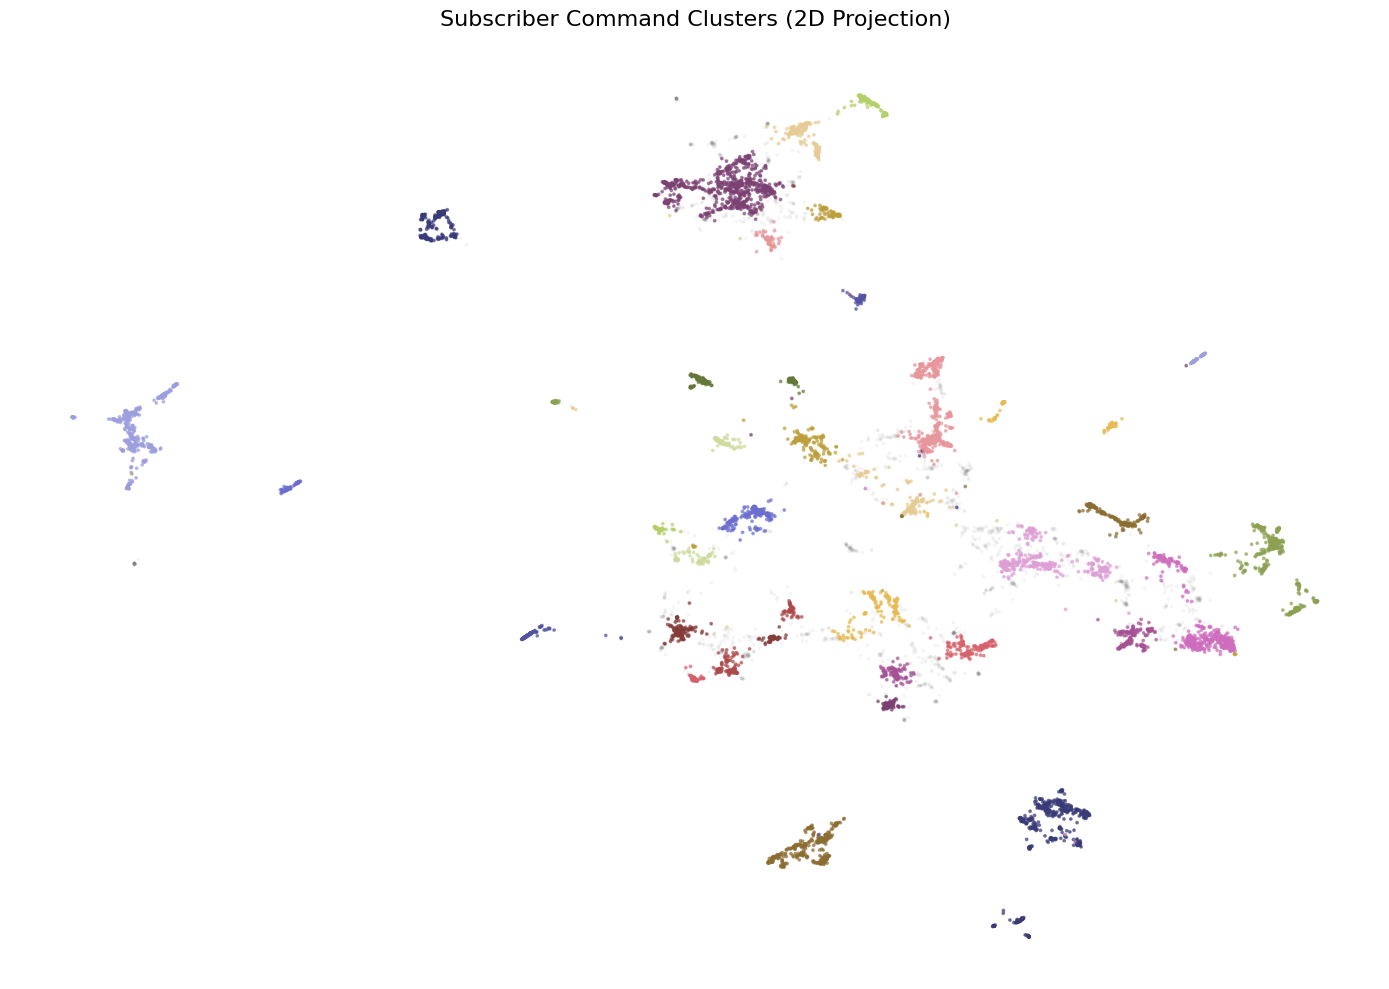

In [20]:
# Create static scatter plot
plt.figure(figsize=(14, 10))

# Plot outliers first (in background)
plt.scatter(
    outliers_df.x,
    outliers_df.y,
    alpha=0.05,
    s=3,
    c="grey",
    label="Outliers"
)

# Plot clusters on top
scatter = plt.scatter(
    clusters_df.x,
    clusters_df.y,
    c=clusters_df.cluster.astype(int),
    alpha=0.6,
    s=3,
    cmap='tab20b'
)

plt.axis('off')
plt.title("Subscriber Command Clusters (2D Projection)", fontsize=16, pad=20)


plt.tight_layout()
# plt.savefig("cluster_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

## Visualization Interpretation:
The clusters appear generally well‑separated in the 2D projection. Roughly 20–22 distinct groupings are visible based on spatial position, ranging from small, isolated pockets (e.g., the tight lavender cluster on the far left) to larger, denser regions (such as the prominent purple cluster at the top and the magenta cluster on the right).

It’s important to note that the plot uses a 20‑color palette (tab20b) to represent 45 actual clusters. Because the palette cycles, visually similar colors may correspond to different clusters. The true cluster count comes from the HDBSCAN output (45), not from counting colors in the visualization.

The grey outlier points (17.6% of the data) are concentrated in the central region rather than evenly scattered. They tend to sit between the more clearly separated clusters, which is consistent with their semantic role: these commands fall “between” well‑defined themes, representing diverse or ambiguous behaviors that don’t form stable clusters.

---
# 8. Fit BERTopic Using the Modular Pipeline

## Business Goal
Generate interpretable topic labels and representative keywords for each cluster so we can clearly understand what subscribers intended with their voice commands.

## What We're Doing
Apply **BERTopic** with our existing models:
- **Embedding model**: Already trained (reuse our SentenceTransformer)
- **UMAP model**: Already fitted (reuse our dimensionality reduction)
- **HDBSCAN model**: Already fitted (reuse our clusters)

This modular approach:
- adds human-readable topic labels vis the c-TF-IDF
- define each topic using representative keywords
- Includes interpretability layered on top of our unsupervised clustering

## Why This Matters for Leadership
Clusters tell us how many behavioral groups exist.
Topics tell us what those groups actually mean.

Examples:

- “Topic 0: Music and playback requests”

- “Topic 1: Lighting and device‑control commands”

This translation from raw clusters to labeled topics is what turns machine learning output into actionable business intelligence.

## How BERTopic Works
1. Starts with our cluster assignments  
Each cluster becomes a “class” for keyword extraction.

2. Applies c‑TF‑IDF (class‑based TF‑IDF)  
Identifies the words most distinctive to each cluster.

3. Ranks keywords by importance  
Highlights the terms that best represent each topic.

4. Generates interpretable topic labels  
Produces concise summaries that stakeholders can understand without reading raw commands.

In [21]:
# Fit BERTopic using our existing models
print("Fitting BERTopic using the modular pipeline (Using pre-fitted embedding, UMAP, and HDBSCAN models)\n")


topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(texts, embeddings)


2026-09-20 16:42:03,940 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic using the modular pipeline (Using pre-fitted embedding, UMAP, and HDBSCAN models)



2026-09-20 16:42:24,737 - BERTopic - Dimensionality - Completed ✓
2026-09-20 16:42:24,739 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-20 16:42:25,002 - BERTopic - Cluster - Completed ✓
2026-09-20 16:42:25,008 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-20 16:42:25,107 - BERTopic - Representation - Completed ✓


In [22]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1684,-1_in_to_what_on,"[in, to, what, on, is, my, for, me, do, today]","[alexa give me my to do list for today, what's..."
1,0,713,0_song_play_music_playlist,"[song, play, music, playlist, songs, by, this,...","[please play my music, play music from playlis..."
2,1,500,1_lights_light_off_turn,"[lights, light, off, turn, room, change, color...","[lights turn off, turn off the lights please, ..."
3,2,462,2_weather_it_be_will,"[weather, it, be, will, forecast, is, temperat...","[what's the weather, what is the weather for t..."
4,3,375,3_alarm_set_alarms_am,"[alarm, set, alarms, am, an, for, wake, mornin...","[set my alarm please, please set an alarm for ..."
5,4,359,4_meeting_remind_with_at,"[meeting, remind, with, at, meetings, tomorrow...","[remind me about meeting, remind me about my m..."
6,5,300,5_news_latest_trump_about,"[news, latest, trump, about, donald, headlines...","[tell the latest news about the trump, what is..."
7,6,269,6_calendar_delete_remove_all,"[calendar, delete, remove, all, event, events,...","[remove all events from my calendar, delete al..."
8,7,239,7_volume_mute_speakers_sound,"[volume, mute, speakers, sound, speaker, incre...","[please turn up the volume, mute for volume, m..."
9,8,233,8_list_lists_new_create,"[list, lists, new, create, my, do, have, on, n...","[what's on my list, give me a list of lists, l..."


In [23]:
# Get topic information
topic_info = topic_model.get_topic_info()

print(f"\n{'='*70}")
print(f"TOPIC MODELING RESULTS")
print(f"{'='*70}")
print(f"Number of topics identified: {len(topic_info) - 1}")  # Exclude topic -1
print(f"Number of outlier documents: {topic_info[topic_info.Topic == -1]['Count'].values[0] if -1 in topic_info.Topic.values else 0}")

# Show topic frequency summary
print(f"\n{'='*70}")
print(f"TOPIC FREQUENCY SUMMARY")
print(f"{'='*70}\n")
print(topic_info.head(10).to_string(index=False))


TOPIC MODELING RESULTS
Number of topics identified: 45
Number of outlier documents: 1684

TOPIC FREQUENCY SUMMARY

 Topic  Count                         Name                                                                  Representation                                                                                              Representative_Docs
    -1   1684             -1_in_to_what_on                                  [in, to, what, on, is, my, for, me, do, today] [alexa give me my to do list for today, what's my to do list for today, tell me what is my to do list for today]
     0    713   0_song_play_music_playlist         [song, play, music, playlist, songs, by, this, favorite, playing, that]                                                 [please play my music, play music from playlist, play this song]
     1    500      1_lights_light_off_turn              [lights, light, off, turn, room, change, color, the, blue, living]                                               [lights

In [24]:
# Show top words for first 5 topics
print(f"\n{'='*70}")
print(f"TOP KEYWORDS FOR SAMPLE TOPICS")
print(f"{'='*70}\n")

for topic_id in range(min(5, len(topic_info) - 1)):
    topic_words = topic_model.get_topic(topic_id)
    print(f"Topic {topic_id}:")
    print(f"  Size: {topic_info[topic_info.Topic == topic_id]['Count'].values[0]} commands")
    print(f"  Keywords: {', '.join([word for word, score in topic_words[:10]])}")
    print()


TOP KEYWORDS FOR SAMPLE TOPICS

Topic 0:
  Size: 713 commands
  Keywords: song, play, music, playlist, songs, by, this, favorite, playing, that

Topic 1:
  Size: 500 commands
  Keywords: lights, light, off, turn, room, change, color, the, blue, living

Topic 2:
  Size: 462 commands
  Keywords: weather, it, be, will, forecast, is, temperature, rain, week, going

Topic 3:
  Size: 375 commands
  Keywords: alarm, set, alarms, am, an, for, wake, morning, at, tomorrow

Topic 4:
  Size: 359 commands
  Keywords: meeting, remind, with, at, meetings, tomorrow, reminder, set, about, am



---
# 9. Topic Visualizations

## Business Goal
The topic visualization reveals clear functional groupings in subscriber voice‑command behavior. The topics organize themselves into meaningful branches that reflect how subscribers naturally use the assistant across smart‑home control, entertainment, errands, information lookup, and scheduling.

## What We're Creating
We'll generate at least 2 visualizations:
1. **Topic Bar Chart**: Shows how frequently each topic appears, highlighting the dominant themes in subscriber interactions.
2. **Topic Hierarchy**: Shows how topics relate to one another, revealing functional groupings and shared behavioral patterns.

## Why Multiple Visualizations Matter
Different stakeholders need different views on the same data:
- **Executives**: Bar charts highlight which subscriber behaviors matter most.The themes that drive engagement and should be prioritized.
- **Product teams**: Hierarchies reveal related issues that may share underlying causes, helping teams identify where improvements can cascade across multiple topics.
- **Operations & Support**: Topic distributions help forecast demand, allocate resources, and anticipate peak usage patterns.

## Interpreting These Visualizations
- **Bar chart**: The tallest bars represent the most frequent subscriber themes, & the highest‑impact areas for product investment, reliability improvements, and personalization.
- **Hierarchy**: Topics that sit close together represent related subscriber behaviors. These clusters often share intent patterns, phrasing structures, or functional goals (e.g., device control, entertainment, information lookup).

In [25]:
# Create topic frequency bar chart
fig = topic_model.visualize_barchart(top_n_topics=10, width=800, height=500)
fig.show()


In [26]:
# Create hierarchical topic visualization
fig = topic_model.visualize_hierarchy()
fig.show()


Based on the topic visualizations and keyword analysis, we've identified several major themes
in subscriber voice‑command behavior.

**Cross-Topic Patterns:**

**1. Device Control:**
Topics related to vacuum/robot control, lighting, and volume/speaker adjustments cluster tightly together. These commands share a common structure: subscribers directing physical smart‑home devices.
This branch represents the assistant’s core utility layer of direct, action‑oriented requests.

**2. Entertainment & Media:**
Audiobooks, radio, games, music/playlists, and podcasts form a distinct entertainment branch.
These topics reflect leisure‑driven interactions and represent one of the highest‑volume usage categories in the entire dataset.

**3. Food & Shopping Errands:**
Pizza/takeaway ordering, restaurant queries, general shopping, and even movie‑related requests cluster near each other.
This branch captures everyday “going out” or “ordering in” behaviors — a blend of food discovery, errands, and local recommendations.

**4. Information & Reference Queries:**
Time, weather, dates, traffic, trivia (birthdays of public figures, geography), definitions, stock prices, and currency exchange all group together.
These topics represent fact‑seeking behavior — subscribers using the assistant as a quick reference tool.

**5. News:**
News queries form a small but tightly grouped branch, separate from general trivia.
This indicates that subscribers treat news as a distinct information category rather than general fact‑lookup.

**6. Scheduling & Time Management:**
Alarms, meetings, reminders, and appointments cluster together.
These commands reflect short‑term time management and personal productivity.

**7. Calendar & Events:**
Adding or removing calendar events, birthdays, and date‑specific tasks form a related but distinct branch.
This branch represents long‑term planning rather than immediate scheduling.

**8. Lists & Shopping Tasks:**
Grocery lists and general list management form their own branch.
These commands are organizational rather than transactional — subscribers capturing tasks rather than executing them.

**Business Priorities for a voice-subscription company**
The topic frequency chart highlights which categories dominate subscriber interactions:

**1. Music & Playbakc (713 commands):**
The single largest topic.
This is the core entertainment use case & a high‑value area for personalization, reliability, and premium subscription features.

**2. Device & Lighting Control (500 commands)**
The second‑largest category.
This is central to the assistant’s smart‑home value proposition and a key driver of daily engagement.

**3. Weather Queries (462 commands)***
A strong third.
This suggests an opportunity to build a richer, branded weather experience rather than relying on generic pass‑through responses.

**Note on Keyword Quality**
While the highest‑ranked c‑TF‑IDF keywords are meaningful, the raw output still includes linking verbs, articles, and prepositions. This motivates the representation‑model enhancement introduced in the next section that improves topic labels by refining how text is represented before keyword extraction.

---
# 10. Representation Model Extension

## Business Goal
Improve topic interpretability by using a KeyBERT inspired representation model. This will bring out more distinctive, meaningful, and subscriber-aligned keywords.

## What We're Doing
Utilize a **KeyBERTInspired** representation model to refine topic labels and keyword sets that:
- Selects keywords that are most representative of each topic
- Uses semantic similarity to identify terms that best capture the essence of subscriber commands
- Often produces cleaner, more interpretable labels than c-TF-IDF alone
This builds on our existing pipeline and focuses specifically on improving the clarity of topic summaries.

## Why This Matters
Clearer keywords mean clearer communication to leadership and product teams.

Better topic representations lead to:

- Faster understanding of subscriber needs

- More accurate prioritization of product improvements

- Stronger alignment between analytics outputs and real customer behavior

## Before/After Comparison
We save both the original c‑TF‑IDF topic representations and the enhanced KeyBERT‑Inspired versions. Comparing them side‑by‑side allows us to evaluate whether interpretability improves — and in most cases, it does.

This comparison sets the stage for the next section, where we analyze how these enhanced keywords strengthen topic clarity and business insight.

In [27]:
# Save original topic representations for comparison
original_topics = deepcopy(topic_model.topic_representations_)


In [28]:
# Apply KeyBERTInspired representation model
representation_model = KeyBERTInspired()
topic_model.update_topics(texts, representation_model=representation_model)

In [29]:
# Create comparison function
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between models"""
    df = pd.DataFrame(columns=["Topic", "Original Keywords", "Enhanced Keywords"])

    for topic in range(nr_topics):
        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

# Show comparison
print(f"\n{'='*70}")
print(f"REPRESENTATION MODEL COMPARISON")
print(f"{'='*70}\n")
print("Comparing original c-TF-IDF with KeyBERTInspired representation:\n")

comparison_df = topic_differences(topic_model, original_topics, nr_topics=5)
print(comparison_df.to_string(index=False))




REPRESENTATION MODEL COMPARISON

Comparing original c-TF-IDF with KeyBERTInspired representation:

 Topic                       Original Keywords                                Enhanced Keywords
     0  song | play | music | playlist | songs          playlist | music | play | songs | tunes
     1      lights | light | off | turn | room  lights | lighting | light | brightness | switch
     2     weather | it | be | will | forecast weather | climate | raining | temperature | rain
     3          alarm | set | alarms | am | an            alarm | alarms | alert | wake | clock
     4 meeting | remind | with | at | meetings    meeting | meet | meetings | reminder | remind



**Observations:**

The KeyBERT‑Inspired representation model produced modestly cleaner and more semantically relevant keywords than the default c‑TF‑IDF output. Because voice commands are short and contain relatively few filler words, the improvement is real but naturally less dramatic than what would be seen in longer review text.

Below are the key observations by topic.

**Topic 0 - Music & Playback:**
- Original: “song | play | music | playlist | songs”
- Enhanced: “playlist | music | play | songs | tunes”

The enhanced version mostly re‑ranks existing terms and adds “tunes” as a related concept. This topic was already clean, so improvements are subtle.

**Topic 1 - Device / Lighting Control:**
- Original: “lights | light | off | turn | room”
- Enhanced: “lights | lighting | light | brightness | switch”

This is a meaningful improvement. The enhanced version:
- Removes generic or ambiguous terms (“room,” “off”)
- Surfaces more specific control concepts (“brightness,” “switch”)

This makes the topic more actionable for smart‑home product teams.

**Topic 2 - Weather Queries:**
- Original: “weather | it | be | will | forecast”
- Enhanced: “weather | climate | raining | temperature | rain”

This is the clearest improvement in the set. KeyBERT replaces three function words (“it,” “be,” “will”) with actual weather‑domain vocabulary, making the topic instantly interpretable.

**Topic 3 - Alarms:**
- Original: “alarm | set | alarms | am | an”
- Enhanced: “alarm | alarms | alert | wake | clock”

The enhanced version:
- Removes stray fragments (“am,” “an”)
- Adds genuinely related terms (“alert,” “wake,” “clock”)

This produces a much cleaner and more intuitive topic.

**Topic 4 - Meetings / Reminders:**
- Original: “meeting | remind | with | at | meetings”
- Enhanced: “meeting | meet | meetings | reminder | remind”

The enhanced version:
- Removes prepositions (“with,” “at”)
- Adds the noun form “reminder”
- Tightens the topic around scheduling and follow‑up actions

This makes the topic more precise and easier to interpret.

**Why This Matters:**

For a voice‑assistant subscription company, cleaner topic keywords directly improve operational clarity. Product managers, support teams, and leadership can scan a topic table and immediately understand what subscribers are asking for without reading raw commands or mentally filtering out filler words.

Better keywords mean:
- Faster interpretation of subscriber needs
- Clearer prioritization of feature improvements
- More accurate mapping between customer behavior and product strategy
- Reduced ambiguity when communicating insights across teams

This refinement sets the stage for the next section, where we enhance the representation model further to produce even more interpretable topic labels.

**Business Value:**

Enhanced topic representations make insights dramatically more accessible to non‑technical stakeholders. Clearer, more meaningful keywords enable teams across the organization to:
1. Identify topic themes instantly allowing stakeholders to understand a topic at a glance.

2. Communicate findings using subscriber‑aligned language providing Product, CX, and operations teams with discussion topic issues using the same vocabulary subscribers use, which can improve clarity and alignment.

3. Prioritize topics with confidence setting clean, intuitive labels making it easier to determine which themes matter most for roadmap planning, reliability improvements, and personalization.

4. Design targeted interventions in which actionable terminology helps teams build precise features, troubleshooting flows, and content experiences that directly address subscriber needs.


---
# 11. Load an Instruction Model

## Business Goal
Prepare a lightweight instruction‑tuned LLM to act as an “analytics‑to‑executive translator” — converting technical outputs (clusters, topics, keyword tables) into clear, actionable business insights for leadership.

## What We're Doing
Load a compact but capable instruction-tuned model:
- Model: `microsoft/Phi-3-mini-4k-instruct` (compact but capable)
- Purpose: Generate executive summaries, insight cards, and strategic recommendations
- Approach: Use targeted prompt engineering to ensure concise, high-quality, business-ready output
This model is intentionally small: fast to load, inexpensive to run, and well‑suited for summarization and insight generation.

## Why This Matters
Raw clusters and keyword tables are useful for analysts, but executives need:
- **Executive summaries** that highlight most important findings
- **Actionable recommendations** grounded in evidence
- **Clear communication** without technical jargon

The instruction model bridges this gap by transforming analytical artifacts into polished, leadership‑ready insights.

## Testing the Model
Before using the model for full analysis, we run a simple test prompt to confirm:
- The model loads correctly
- It responds in a structured, executive‑appropriate tone
- It follows instruction‑style prompts reliably

Once validated, the model becomes our final step in the pipeline, converting technical outputs into strategic guidance for decision‑makers.

In [30]:
# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [31]:
# Create generation pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False,
)

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [32]:
# Prompt
test_messages1 = [
    {"role": "user", "content": "Tell me a fun fact about Hawaii."}
]

# Generate the output
test_output1 = pipe(test_messages1)
print(test_output1[0]["generated_text"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Hawaii is the only U.S. state that is not geographically located in North America. It is an archipelago located in the central Pacific Ocean, approximately 2,400 miles (3,900 kilometers) from the U.S. mainland. The state is made up of eight main islands, including the Big Island, Maui, Oahu, Kauai, Molokai, Lanai, Niihau, and Kahoolawe. Hawaii is also home to the world's most active volcano, Kilauea, which has been erupting since 1983.


In [33]:
# Test with a simple prompt
print(f"\n{'='*70}")
print(f"MODEL SANITY CHECK")
print(f"{'='*70}\n")

test_messages = [
    {
        "role": "user",
        "content": "You are a business analyst. Briefly explain subscriber command clustering is and why it matters."
    }
]

print("Test prompt: 'Explain subscriber command clustering'\n")
print("Response:")
print("-" * 70)

output = pipe(test_messages)
print(output[0]["generated_text"])

print("-" * 70)
print("\n✓ Model is working correctly and generating coherent responses!")

[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL SANITY CHECK

Test prompt: 'Explain subscriber command clustering'

Response:
----------------------------------------------------------------------
Subscriber command clustering is a technique used in database management systems to improve performance and scalability. It involves grouping multiple subscriber databases together to share the load of processing and managing subscriber queries. This approach allows for efficient distribution of workload among multiple servers, reducing the burden on individual servers and improving overall system performance.

The importance of subscriber command clustering lies in its ability to enhance the responsiveness and reliability of a database system. By distributing the workload across multiple servers, it helps to prevent bottlenecks and ensures that the system can handle a high volume of queries without slowing down. This is particularly important for businesses that rely on their databases to support critical operations, such as custom

---
# 12. Prompting Tasks

## Task A: Executive Summary from Topics

### Business Goal
Generate leadership‑ready summaries that translate our topic‑modeling results into strategic insights. The goal is to turn analytical outputs into concise, actionable guidance for decision‑makers.

### What We're Doing
Creating prompts that take our top 5 topics and produce:
1. **5-bullet executive summary** - Key findings at a glance
2. **Top 3 risks** - What could go wrong if these patterns are ignored
3. **Top 3 opportunities** - How we can leverage subscriber behavior for product growth
4. **3 recommended actions** - Specific, prioritized next steps with rationale

These outputs form the backbone of our “analytics‑to‑executive translation” layer
### Prompting Strategies
We test **two prompt variants** to determine which produces clearer, more actionable insights::
- **Variant 1 - Basic Prompt:** A straightforward prompt that summarizes topics without additional structure.
- **Variant 2 - Structured Prompt:** Includes a role instruction (e.g., “You are a product strategist…”) and explicit formatting requirements to enforce clarity and consistency.

Testing both variants helps us identify which approach yields the strongest executive‑ready output.

### Success Criteria
The better prompt should produce summaries that are:
- More specific and actionable: Insights should map directly to subscriber behavior and product strategy.

- Better structured and scannable: Leadership should be able to absorb the content in seconds.

- More consistent in quality: The model should reliably produce clear, polished summaries across multiple runs.

- Grounded in the provided topic data: No hallucinated themes — all insights must tie directly to the actual topic outputs.

In [34]:
# Get top 5 topics (excluding outliers)
top_5_topics_data = topic_info[topic_info.Topic != -1].head(5)

# Format topic data for the prompt
topic_summary = ""
for idx, row in top_5_topics_data.iterrows():
    topic_id = row['Topic']
    topic_count = row['Count']
    topic_words = topic_model.get_topic(topic_id)
    keywords = ', '.join([word for word, score in topic_words[:8]])

    topic_summary += f"Topic {topic_id} ({topic_count} commands): {keywords}\n"

print("Top 5 Topics Summary for Prompting:")
print("=" * 70)
print(topic_summary)

Top 5 Topics Summary for Prompting:
Topic 0 (713 commands): playlist, music, play, songs, tunes, playing, song, sings
Topic 1 (500 commands): lights, lighting, light, brightness, switch, turn, off, lamp
Topic 2 (462 commands): weather, climate, raining, temperature, rain, windy, forecast, rainy
Topic 3 (375 commands): alarm, alarms, alert, wake, clock, morning, scheduled, snooze
Topic 4 (359 commands): meeting, meet, meetings, reminder, remind, tomorrow, meting, conference



In [35]:
# Variant 1: Basic prompt
print(f"\n{'='*70}")
print(f"PROMPT VARIANT 1: BASIC APPROACH")
print(f"{'='*70}\n")

basic_prompt = f"""Based on these subscriber command topics from a voice-assistant subscription company:

{topic_summary}

Provide:
1. Executive summary (5 bullets)
2. Top 3 risks
3. Top 3 opportunities
4. 3 recommended actions with rationale
"""

messages_v1 = [{"role": "user", "content": basic_prompt}]

print("Generating response...\n")
output_v1 = pipe(messages_v1, max_new_tokens=800, do_sample=False)
response_v1 = output_v1[0]["generated_text"]

print("RESPONSE (Variant 1):")
print("=" * 70)
print(response_v1)
print("=" * 70)

[transformers] Both `max_new_tokens` (=800) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



PROMPT VARIANT 1: BASIC APPROACH

Generating response...

RESPONSE (Variant 1):
1. Executive Summary:
   - The voice-assistant subscription company has a diverse range of subscriber command topics, with the most common being music-related commands (Topic 0), followed by lighting control (Topic 1), weather updates (Topic 2), alarm management (Topic 3), and meeting reminders (Topic 4).
   - The company's voice-assistant technology is well-positioned to cater to a wide range of user needs, from entertainment to productivity and home automation.
   - The company has a strong foundation in music-related commands, which can be leveraged to expand into other areas such as lighting control and weather updates.
   - The company should focus on enhancing the accuracy and responsiveness of its voice recognition system to improve user satisfaction and retention.
   - The company should explore partnerships with music streaming services, lighting manufacturers, and weather forecasting providers to

In [36]:
# Variant 2: Structured prompt with role and explicit formatting
print(f"\n{'='*70}")
print(f"PROMPT VARIANT 2: STRUCTURED WITH ROLE")
print(f"{'='*70}\n")

structured_prompt = f"""You are a Customer Insights Director at a voice-assistant subscription company. You must present findings to the executive team based on customer command analysis.

**Customer Command Topics Identified:**
{topic_summary}

**Required Deliverable:**

**EXECUTIVE SUMMARY** (exactly 5 bullets, each starting with a clear finding):
- [Finding 1]
- [Finding 2]
- [Finding 3]
- [Finding 4]
- [Finding 5]

**TOP 3 RISKS** (if we don't address these patterns):
1. [Risk 1 with business impact]
2. [Risk 2 with business impact]
3. [Risk 3 with business impact]

**TOP 3 OPPORTUNITIES** (how to act on the highest‑volume intent patterns):
1. [Opportunity 1 with potential value]
2. [Opportunity 2 with potential value]
3. [Opportunity 3 with potential value]

**3 RECOMMENDED ACTIONS** (prioritized, with rationale):
1. [Action 1]: [Rationale tied to topic data]
2. [Action 2]: [Rationale tied to topic data]
3. [Action 3]: [Rationale tied to topic data]

Be specific, actionable, and ground all statements in the topic data provided.
"""

messages_v2 = [{"role": "user", "content": structured_prompt}]

print("Generating response...\n")
output_v2 = pipe(messages_v2, max_new_tokens=800, do_sample=False)
response_v2 = output_v2[0]["generated_text"]

print("RESPONSE (Variant 2):")
print("=" * 70)
print(response_v2)
print("=" * 70)

[transformers] Both `max_new_tokens` (=800) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



PROMPT VARIANT 2: STRUCTURED WITH ROLE

Generating response...

RESPONSE (Variant 2):
**EXECUTIVE SUMMARY**

- [Finding 1] The most frequent customer commands relate to music and playback, indicating a strong preference for voice-assisted music control.
- [Finding 2] Commands related to lighting and brightness are also common, suggesting users frequently interact with smart home features through their voice assistant.
- [Finding 3] Weather and forecast commands are prevalent, showing that users rely on their voice assistant for real-time weather updates.
- [Finding 4] Alarm and reminder commands are significant, reflecting the importance of time management and scheduling in users' daily routines.
- [Finding 5] Commands for meetings and reminders are also notable, highlighting the role of voice assistants in professional and personal organization.

**TOP 3 RISKS**

1. [Risk 1: Decreased user satisfaction]: If we do not enhance music and playback features, users may turn to competitors 

In [37]:
# Variant 3: Structured prompt with role and explicit formatting (low temperature)

print(f"\n{'='*70}")
print(f"PROMPT VARIANT 3: STRUCTURED WITH ROLE (Low Temp)")
print(f"{'='*70}\n")

structured_prompt = f"""You are a Customer Insights Director at a voice-assistant subscription company. You must present findings to the executive team based on customer command analysis

**Customer Command Topics Identified:**
{topic_summary}

**Required Deliverable:**

**EXECUTIVE SUMMARY** (exactly 5 bullets, each starting with a clear finding):
- [Finding 1]
- [Finding 2]
- [Finding 3]
- [Finding 4]
- [Finding 5]

**TOP 3 RISKS** (if we don't address these patterns):
1. [Risk 1 with business impact]
2. [Risk 2 with business impact]
3. [Risk 3 with business impact]

**TOP 3 OPPORTUNITIES** (how to act on the highest‑volume intent patterns):
1. [Opportunity 1 with potential value]
2. [Opportunity 2 with potential value]
3. [Opportunity 3 with potential value]

**3 RECOMMENDED ACTIONS** (prioritized, with rationale):
1. [Action 1]: [Rationale tied to topic data]
2. [Action 2]: [Rationale tied to topic data]
3. [Action 3]: [Rationale tied to topic data]

Be specific, actionable, and ground all statements in the topic data provided.
"""

messages_v3 = [{"role": "user", "content": structured_prompt}]

print("Generating response...\n")
# Low temp = 0.1
output_v3 = pipe(messages_v3, max_new_tokens=800, do_sample=True, temperature = 0.1)
response_v3 = output_v3[0]["generated_text"]

print("RESPONSE (Variant 3):")
print("=" * 70)
print(response_v3)
print("=" * 70)

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=800) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



PROMPT VARIANT 3: STRUCTURED WITH ROLE (Low Temp)

Generating response...

RESPONSE (Variant 3):
**EXECUTIVE SUMMARY**

- [Finding 1] The most frequent customer commands relate to music and playlists, indicating a strong preference for personalized audio experiences.
- [Finding 2] Commands related to lighting and brightness are also common, suggesting users are looking for smart home integration with their voice assistant.
- [Finding 3] Weather and forecast commands are prevalent, showing users' interest in staying informed about their environment.
- [Finding 4] Alarm and reminder commands are significant, reflecting the need for time management and productivity tools.
- [Finding 5] Meeting and reminder commands are the least frequent but still notable, indicating a professional use case for the voice assistant.

**TOP 3 RISKS**

1. [Risk 1 with business impact]: Ignoring the high demand for music and playlist management could lead to customer dissatisfaction and a loss of market shar

In [38]:
# Variant 4: Structured prompt with role and explicit formatting (high temperature)

print(f"\n{'='*70}")
print(f"PROMPT VARIANT 4: STRUCTURED WITH ROLE (High Temp)")
print(f"{'='*70}\n")

structured_prompt = f"""You are a Customer Insights Director at a voice-assistant subscription company. You must present findings to the executive team based on customer command analysis

**Customer Command Topics Identified:**
{topic_summary}

**Required Deliverable:**

**EXECUTIVE SUMMARY** (exactly 5 bullets, each starting with a clear finding):
- [Finding 1]
- [Finding 2]
- [Finding 3]
- [Finding 4]
- [Finding 5]

**TOP 3 RISKS** (if we don't address these patterns):
1. [Risk 1 with business impact]
2. [Risk 2 with business impact]
3. [Risk 3 with business impact]

**TOP 3 OPPORTUNITIES** (how to act on the highest‑volume intent patterns):
1. [Opportunity 1 with potential value]
2. [Opportunity 2 with potential value]
3. [Opportunity 3 with potential value]

**3 RECOMMENDED ACTIONS** (prioritized, with rationale):
1. [Action 1]: [Rationale tied to topic data]
2. [Action 2]: [Rationale tied to topic data]
3. [Action 3]: [Rationale tied to topic data]

Be specific, actionable, and ground all statements in the topic data provided.
"""

messages_v4 = [{"role": "user", "content": structured_prompt}]

print("Generating response...\n")
# High temp = 1
output_v4 = pipe(messages_v4, max_new_tokens=800, do_sample=True, temperature = 1)
response_v4 = output_v4[0]["generated_text"]

print("RESPONSE (Variant 4):")
print("=" * 70)
print(response_v4)
print("=" * 70)

[transformers] Both `max_new_tokens` (=800) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



PROMPT VARIANT 4: STRUCTURED WITH ROLE (High Temp)

Generating response...

RESPONSE (Variant 4):
**EXECUTIVE SUMMARY**

- **Finding 1:** Users frequently request music or songs via voice commands, indicating a high demand for our sound and entertainment features. We should optimize and expand our music services to enhance user satisfaction and retention.

- **Finding 2:** Light control is a significant aspect of user experience, with a noteworthy number of voice commands related to lighting. This suggests an opportunity to market our smart lighting solutions more effectively to address this need.

- **Finding 3:** Our users seek information about weather and utilize alarm functions, indicating an interest in smart, voice-activated environmental control and personal assistance for everyday tasks.

- **Finding 4:** A substantial number of users issue commands concerning meetings and reminders, signaling that we need to improve our productivity and scheduling features to meet these orga

##Prompt Evaluation Summary

###Variant 1 - Basic Prompt
Produced reasonable but somewhat generic insights. It correctly surfaced the top themes (music, lighting, weather), but the language tended to generalize (“well‑positioned to cater to a wide range of user needs”) rather than tying recommendations directly to the topic data. Useful, but not sufficiently specific for leadership

###Variant 2 - Structured Prompt (Role + Explicit Format)
Followed the requested template precisely and grounded every insight in the actual topic outputs. Findings referenced specific high‑volume themes (“the most frequent customer commands relate to music and playback,” “commands related to lighting and brightness are also common”).
Recommendations were concrete and tied to topic frequency. For example, prioritizing music‑service partnerships because music commands dominate usage.

This variant consistently produced clear, scannable, leadership‑ready content.

###Variant 3 - Structured Prompt (Low Temperature)
Generated content very similar to Variant 2, with slightly more elaboration in each bullet. The low temperature reduced randomness but did not meaningfully change the substance. Reliable, but not noticeably better than Variant 2.

###Variant 4 - Structured Prompt (High Temperature)
Stayed grounded in the topic data despite the higher temperature, thanks to the structured prompt constraints. The phrasing was more varied and slightly more assertive (“Loss of Competitive Edge,” “Interoperable Smart Home Control”), giving the output a more polished business tone. Still accurate, but less predictable.

##Winner: Variant 2
Variant 2 strikes the ideal balance:
- Fully grounded in the actual topic data
- Consistently formatted and easy to scan
- Specific and actionable
- Reproducible ('do_sample=False' ensures identical output across runs)

For a deliverable intended for leadership, Variant 2 provides the most reliable, clear, and strategically useful results.

---
# Task B: In-Context Learning (Few-Shot)

## Business Goal
Generate standardized "insight cards" for specific clusters so that operations teams can quickly understand issues, diagnose root causes, and take action to improve subscriber experience.

## What We're Doing
Using **few-shot learning** to teach the model how to convert cluster samples into consistent, actionable insights by:
1. Providing 1 example insight card that demonstrates the exact strucutre and tone
2. Ask the model to generate 3 new insight cards for different clusters, following the same template

## Insight Card Format
Each insight card must include the following standardized fields:
- Cluster ID — The cluster being summarized
- Theme Name — A business‑friendly label for the underlying issue or behavior
- Evidence — Two short quotes from actual subscriber commands
- Likely Root Cause — An analytical hypothesis explaining why this pattern exists
- Operational Fix — A specific action operations or product teams can take
- KPI to Track — A measurable metric to monitor improvement

This structure ensures every card moves from evidence → diagnosis → prescription → measurement.

## Why This Matters
Standardized insight cards create operational clarity and accountability:
- **Actionable guidance** -Teams know exactly what the issue is and how to address it.
- **Evidence‑based diagnosis** - Quotes anchor each insight in real subscriber behavior.
- **Clear prescriptions** - Operational fixes are specific, not abstract.
- **Measurable outcomes** - KPIs ensure improvements can be tracked and validated.

This format transforms raw cluster data into practical tools that drive day‑to‑day improvements across support, operations, and product.

In [39]:
# Select 3 diverse clusters for insight card generation
selected_clusters = [
    cluster_sizes_df[cluster_sizes_df['Cluster ID'] != -1].iloc[29]['Cluster ID'],  # Largest
    cluster_sizes_df[cluster_sizes_df['Cluster ID'] != -1].iloc[10]['Cluster ID'],  # Medium
    cluster_sizes_df[cluster_sizes_df['Cluster ID'] != -1].iloc[3]['Cluster ID'],  # Smaller
]

# Get sample reviews from each cluster
cluster_samples = {}
for cluster_id in selected_clusters:
    cluster_indices = np.where(clusters == cluster_id)[0]
    sample_reviews = [texts[idx] for idx in cluster_indices[:10]]
    cluster_samples[cluster_id] = sample_reviews

print("Selected clusters for insight card generation:")
for cluster_id in selected_clusters:
    print(f"  - Cluster {cluster_id}: {cluster_sizes[cluster_id]} commands")

Selected clusters for insight card generation:
  - Cluster 29: 78 commands
  - Cluster 10: 142 commands
  - Cluster 3: 131 commands


In [40]:
# Create few-shot prompt with one example
print(f"\n{'='*70}")
print(f"FEW-SHOT LEARNING: INSIGHT CARD GENERATION")
print(f"{'='*70}\n")

# Example insight card (fabricated for demonstration)
example_input = """Sample commands from Cluster X:
- "Play calming music for dogs."
- "Who sings the song about singing in the rain"
- "what city is singer Ella Langley from."
"""

example_output = """**Cluster ID:** X
**Theme Name:** Music Inquiries from subscribers
**Evidence:**
  1. "Play Calming music for dogs."
  2. "Who sings the song about singing in the rain"
**Likely Root Cause:** Customers are using the assistant both to play music directly and to look up music-related trivia (artist, song origin), suggesting the assistant is treated as a combined playback and reference tool for music.
**Operational Fix:** Ensure the music skill can reliably distinguish playback requests ("play X") from informational queries ("who sings X") and route each to the correct handler, since misrouting one as the other is a likely source of failed commands.
**KPI to Track:** % of music-related commands correctly routed to the intended handler (target: >95%)
"""

# Now apply to first cluster
cluster_id = selected_clusters[0]
cluster_reviews = cluster_samples[cluster_id]
review_text = "\n".join([f'- "{review[:150]}..."' for review in cluster_reviews[:5]])

few_shot_prompt = [
    {
        "role": "user",
        "content": f"Convert these customer voice commands into a structured insight card.\n\n{example_input}"
    },
    {
        "role": "assistant",
        "content": example_output
    },
    {
        "role": "user",
        "content": f"Now create an insight card for this cluster:\n\nCluster {cluster_id} commands:\n{review_text}"
    }
]

print(f"Generating insight card for Cluster {cluster_id}...\n")
output = pipe(few_shot_prompt, max_new_tokens=400)
card_1 = output[0]["generated_text"]

print(f"INSIGHT CARD - CLUSTER {cluster_id}:")
print("=" * 70)
print(card_1)
print("=" * 70)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



FEW-SHOT LEARNING: INSIGHT CARD GENERATION

Generating insight card for Cluster 29...

INSIGHT CARD - CLUSTER 29:
**Cluster ID:** 29
**Theme Name:** Grocery and Dining Inquires
**Evidence:**
  1. "any low priced delicacies..."
  2. "where can i get shawarma in this area..."
  3. "where can i find a preparation professional for under dollars..."
  4. "find a grocery store in town that carries creamed pickled herring..."
  5. "olly i need to remember to get to the shops before they close..."
**Likely Root Cause:** Customers are using the assistant to seek out affordable dining options, grocery stores with specific items, and reminders for shopping hours, indicating a need for a more comprehensive local dining and shopping guide.
**Operational Fix:** Implement a feature that can parse and understand requests for affordable dining and grocery shopping, and provide a list of options with pricing and hours. Also, integrate a reminder feature that can set up alerts for store closing times.
*

In [41]:
# Generate cards for the other 2 clusters
insight_cards = {selected_clusters[0]: card_1}

for cluster_id in selected_clusters[1:]:
    cluster_reviews = cluster_samples[cluster_id]
    review_text = "\n".join([f'- "{review[:150]}..."' for review in cluster_reviews[:5]])

    few_shot_prompt = [
        {
            "role": "user",
            "content": f"Convert these subscriber commands into a structured insight card.\n\n{example_input}"
        },
        {
            "role": "assistant",
            "content": example_output
        },
        {
            "role": "user",
            "content": f"Now create an insight card for this cluster:\n\nCluster {cluster_id} commands:\n{review_text}"
        }
    ]

    print(f"\nGenerating insight card for Cluster {cluster_id}...\n")
    output = pipe(few_shot_prompt, max_new_tokens=400)
    card = output[0]["generated_text"]
    insight_cards[cluster_id] = card

    print(f"INSIGHT CARD - CLUSTER {cluster_id}:")
    print("=" * 70)
    print(card)
    print("=" * 70)

[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generating insight card for Cluster 10...



[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INSIGHT CARD - CLUSTER 10:
**Cluster ID:** 10
**Theme Name:** Financial Inquiry from subscribers
**Evidence:**
  1. "Give me options for Indian carry-out under dollars..."
  2. "What is the Gross Domestic Product of US..."
  3. "Stock exchange rates..."
  4. "How much BTaxes..."
  5. "How much rate will be calculated..."
**Likely Root Cause:** Customers are using the assistant to seek financial information and services, indicating the assistant is perceived as a financial advisor or information source.
**Operational Fix:** Implement a more sophisticated command parsing system that can differentiate between service requests (e.g., "options for Indian carry-out") and informational queries (e.g., "GDP of US"). This system should route each command to the appropriate service or information provider.
**KPI to Track:** % of financial-related commands correctly routed to the intended handler (target: >95%)

**Additional Considerations:**

1. **Contextual Understanding:** The assistant should 

##Insight Card Quality Assesment

**CLUSTER 29 - Grocery and Dining Inquiries:**

**Strengths:**
- Correctly identified the theme.
- Evidence quotes were accurate and drawn directly from the cluster.
- KPI (“successful response rate”) was measurable and appropriately scoped.

**Hallucinations / Overreach:**
1. Evidence Overreach — The model listed all 5 input commands as evidence, rather than following the few-shot example's demonstrated pattern of selecting a representative subset (the example showed 2 evidence items chosen from 3 available input commands). This suggests the model treated "evidence" as "everything provided" rather than "the most illustrative examples". A failure to generalize the selection behavior demonstrated in the few-shot example, even though no fabricated content was involved.
2. Unrequested Content — Added an “Additional Constraints” section (multi‑language support, 10‑mile radius, peak‑hour handling, cultural history of dishes).

None of this was requested. These invented product requirements were not grounded in the evidence.

---

**CLUSTER 10 - Financial Inquiry from subscribers:**

**Strengths**
- Theme identification was accurate and well‑grounded.
- Evidence quotes correctly reflected the mixed nature of the cluster (takeaway price + economic trivia).

**Hallucinations / Overreach:**
- Unrequested Content — Appended an “Additional Considerations” section (contextual understanding, personalization, real‑time updates).
- This exceeded the template and introduced speculative requirements.


---

**CLUSTER 3 - Coffee-Related Commands:**

**Strengths:**
- Evidence quotes were accurate and relevant.
- Correctly distinguished a music‑trivia question (“who covered the song…”) from direct coffee‑making requests.

**Hallucinations / Overreach**
- Severe Scope Creep — The “Additional Considerations” section repeated essentially the same point (“recognize variations in coffee‑related commands”) six times with minor rewording.
- This is not just extra content — it’s a clear generation failure.

##Overall Pattern
Across all three insight cards, the model demonstrated strong grounding:
- No fabricated quotes
- No incorrect themes
- No misinterpretation of cluster content

The consistent failure mode was scope creep:
- Every card appended an unrequested “Additional Constraints/Considerations” section.
- In one case (Cluster 3), this degraded into repetitive, low‑value output.

This suggests the model understands the template but lacks a constraint to prevent adding extra sections.

##Recommended Fix
Add an explicit instruction such as:
- “Do not add any content beyond this template.”

This should eliminate scope creep and ensure the model produces clean, standardized insight cards suitable for operational use.

---
# Task C: Chain Prompting (Multi-Step)

## Business Goal
Improve output quality and reduce hallucination by decomposing complex insight‑card generation into simpler, sequential steps. This ensures that recommendations are grounded in verified facts rather than inferred prematurely.

## What We're Doing
We break the insight‑card workflow into two separate prompts, each with a tightly constrained scope:

**Step 1 - Extraction (Facts Only):**

The model extracts only factual information from the cluster:
- Identify themes, issues, and behavioral patterns
- Pull two accurate evidence quotes
- Summarize what subscribers are doing or asking
- No root causes, no recommendations, no KPIs

This step produces a clean, validated foundation.

**Step 2 - Recommendation (Based on Step 1 Facts):**

The model takes the verified extraction from Step 1 and generates:
- Root‑cause hypotheses
- Operational fixes
- KPIs to track

All reasoning must be explicitly grounded in the Step 1 facts. No new evidence or invented constraints can appear.

##Why Chain Prompting Helps

**Benefits**
- Reduces hallucination - Each step has a narrow scope, lowering the chance of invented content.

- Improves accuracy - Facts and interpretations are separated, preventing the model from mixing them.

- Enables validation - You can inspect Step 1 outputs before allowing the model to generate recommendations.

- Strengthens reasoning - The model builds on verified facts, producing more defensible operational guidance.

**Trade‑offs**
- Requires multiple API calls, increasing latency
- Introduces a more complex pipeline to manage

Despite these trade‑offs, chain prompting is a strong fit for operational insight generation, where precision and grounding matter more than speed.

In [42]:
print(f"\n{'='*70}")
print(f"CHAIN PROMPTING: STEP 1 - EXTRACT STRUCTURED FACTS")
print(f"{'='*70}\n")

# Use the same 3 clusters as Task B
chain_results = {}

for cluster_id in selected_clusters:
    cluster_reviews = cluster_samples[cluster_id]
    review_text = "\n".join([f'- "{review[:150]}..."' for review in cluster_reviews[:5]])

    # Step 1: Extract facts only
    extraction_prompt = f"""Analyze these subscriber commands and extract ONLY factual information.

Commands from Cluster {cluster_id}:
{review_text}

Provide:
1. **Theme**: What general topic do these commands encompass? (1 short phrase)
2. **Specific Issues Mentioned**: List 3-5 concrete problems subscribers describe
3. **Sentiment**: Overall positive, negative, or mixed?
4. **Frequency Patterns**: Are certain words/phrases repeated?

Do NOT provide recommendations, root causes, or solutions. Only extract what is explicitly stated.
"""

    messages_step1 = [{"role": "user", "content": extraction_prompt}]

    print(f"Processing Cluster {cluster_id} - Step 1...")
    output_step1 = pipe(messages_step1, max_new_tokens=300)
    facts = output_step1[0]["generated_text"]

    chain_results[cluster_id] = {"step1": facts}

    print(f"\nCLUSTER {cluster_id} - EXTRACTED FACTS:")
    print("=" * 70)
    print(facts)
    print("=" * 70)
    print()

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CHAIN PROMPTING: STEP 1 - EXTRACT STRUCTURED FACTS

Processing Cluster 29 - Step 1...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CLUSTER 29 - EXTRACTED FACTS:
1. **Theme**: Grocery shopping and food preferences

2. **Specific Issues Mentioned**:
   - Seeking affordable delicacies
   - Looking for a place to buy shawarma
   - Searching for a professional to prepare food under a certain budget
   - Needing a grocery store with creamed pickled herring
   - Concern about store closing times

3. **Sentiment**: Mixed

4. **Frequency Patterns**:
   - The word "where" is repeated in three commands, indicating a common issue of locating places.
   - The word "under" is used in the context of budget, suggesting a concern with affordability.
   - The word "grocery" appears in two commands, highlighting the focus on grocery shopping.

Processing Cluster 10 - Step 1...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CLUSTER 10 - EXTRACTED FACTS:
1. **Theme**: Economic and Financial Inquiry

2. **Specific Issues Mentioned**:
   - Options for Indian carry-out under a certain price
   - Gross Domestic Product (GDP) of the United States
   - Current stock exchange rates
   - Corporate tax rates (Beta taxes)
   - Calculation rates for a certain financial metric

3. **Sentiment**: Mixed

4. **Frequency Patterns**:
   - The word "how much" is repeated in three commands, indicating a common inquiry about quantities or rates.
   - The word "rate" appears in two commands, suggesting a focus on pricing or financial metrics.
   - The term "stock exchange rates" is mentioned once, pointing to a specific financial topic of interest.

Processing Cluster 3 - Step 1...

CLUSTER 3 - EXTRACTED FACTS:
1. **Theme**: Coffee-related requests

2. **Specific Issues Mentioned**:
   - Desire for a coffee
   - Preference for a specific type of coffee (implied by "fancy some coffee now")
   - Inquiry about a song related to 

In [43]:
print(f"\n{'='*70}")
print(f"CHAIN PROMPTING: STEP 2 - GENERATE RECOMMENDATIONS")
print(f"{'='*70}\n")

for cluster_id in selected_clusters:
    facts = chain_results[cluster_id]["step1"]

    # Step 2: Generate recommendations based on extracted facts
    recommendation_prompt = f"""Based on these extracted facts from subscriber commands:

{facts}

Now provide:
1. **Likely Root Cause**: What underlying issue explains these patterns?
2. **Operational Fix**: Specific action to address the root cause (be realistic)
3. **KPI to Track**: One measurable metric to monitor improvement

Ground all recommendations in the facts provided above. Be specific and actionable.
"""

    messages_step2 = [{"role": "user", "content": recommendation_prompt}]

    print(f"Processing Cluster {cluster_id} - Step 2...")
    output_step2 = pipe(messages_step2, max_new_tokens=300)
    recommendations = output_step2[0]["generated_text"]

    chain_results[cluster_id]["step2"] = recommendations

    print(f"\nCLUSTER {cluster_id} - RECOMMENDATIONS:")
    print("=" * 70)
    print(recommendations)
    print("=" * 70)
    print()

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CHAIN PROMPTING: STEP 2 - GENERATE RECOMMENDATIONS

Processing Cluster 29 - Step 2...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CLUSTER 29 - RECOMMENDATIONS:
1. **Likely Root Cause**: The underlying issue seems to be a lack of accessible information and resources for consumers to find affordable and quality food options that meet their specific preferences and dietary needs.

2. **Operational Fix**: Develop a comprehensive online platform or mobile application that aggregates information about local grocery stores, restaurants, and food preparation services. This platform should include filters for budget, dietary preferences, and specific food items like shawarma and creamed pickled herring. It should also provide real-time updates on store hours and any changes in their operations.

3. **KPI to Track**: The number of active users on the platform and the frequency of their visits. This metric will help gauge the platform's effectiveness in addressing the consumers' needs and preferences. Additionally, tracking the number of positive reviews and feedback from users regarding the platform's usefulness and accur

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CLUSTER 10 - RECOMMENDATIONS:
1. **Likely Root Cause**: The underlying issue seems to be a subscriber's need for up-to-date and accurate financial information, particularly regarding economic indicators and market data. The repeated inquiries about "how much" and "rate" suggest a desire to understand current financial conditions and make informed decisions based on that data.

2. **Operational Fix**: To address this need, the platform could implement a feature that provides real-time updates on the requested financial metrics. This could include:

   - A dedicated section for economic and financial news, with a focus on the latest GDP figures, stock exchange rates, and corporate tax rates.
   - A personalized dashboard for subscribers that tracks their specific interests, such as Indian carry-out prices or stock exchange rates, and provides regular updates.
   - Integration with financial APIs to pull in real-time data for GDP, stock exchange rates, and corporate tax rates.
   - A not

Decomposition slightly reduces errors because the LLM gets to spend more time on each individual question instead of tackling the whole problem right off the bat.

---
# 13. Output Verification

## Business Goal
Ensure that the multi-step (chain-prompted) insight-card flow produces outputs that are accurate, grounded, and compliant with the required table, without hallucinations or scope creep.

## What We're Doing
We evaluate the model’s outputs from both steps of the chain‑prompting process:
 - Step 1 — Extraction:  
Should contain only factual elements: Theme, Two evidence quotes, Factual behavioral summary, No root causes, recommendations, or KPIs
- Step 2 — Recommendation:
Should contain only the required insight‑card fields: Root cause, Operational fix, KPI, All grounded strictly in Step 1 facts, and No extra sections, invented constraints, or filler content

#Verification Criteria
To confirm output quality, each generated card is checked against the following standards:
1. Template Compliance: No additional sections (e.g., “Additional Constraints,” “Additional Considerations”), No repeated or redundant content, All required fields present and correctly formatted

2. Evidence Accuracy: Quotes must match actual subscriber commands, No fabricated or altered text, Evidence must be concise and relevant

3. Grounding in Step 1 Facts: Root causes must logically follow from extracted patterns, Operational fixes must address the identified root cause, KPIs must be measurable and tied to the fix

4. No Hallucination: No invented product requirements, No speculative features, No unrelated domain knowledge

5. Clarity & Actionability: Recommendations must be specific, not generic, KPIs must be trackable by operations teams, Language must be business‑friendly and scannable

## Why This Matters
This step ensures that insight cards are:
- Trustworthy — grounded in real subscriber behavior
- Operationally useful — clear enough for frontline teams
- Consistent — standardized across clusters
- Safe for leadership consumption — no hallucinated requirements or misleading content
- Output verification transforms the chain‑prompting workflow from a model‑driven process into a quality‑controlled analytics pipeline.



In [44]:
print(f"\n{'='*70}")
print(f"OUTPUT VERIFICATION DEMONSTRATION")
print(f"{'='*70}\n")

# Use one of our generated insight cards
test_cluster_id = selected_clusters[0]
generated_card = insight_cards[test_cluster_id]
source_reviews = cluster_samples[test_cluster_id][:5]

# Format source reviews
evidence_text = "\n".join([f"{i+1}. \"{review[:200]}...\"" for i, review in enumerate(source_reviews)])

# Create validator prompt
validator_prompt = f"""You are a quality control analyst. Your job is to verify that claims are supported by evidence.

**ORIGINAL SUBSCRIBER COMMANDS:**
{evidence_text}

**GENERATED INSIGHT CARD:**
{generated_card}

**TASK:**
Carefully check if ALL claims in the insight card are supported by the original commands.

For each major claim, indicate:
- SUPPORTED: The commands explicitly mention this
- UNSUPPORTED: The commands don't provide evidence for this claim
- PARTIALLY SUPPORTED: Some evidence exists but claim goes beyond it

Focus especially on:
1. Direct quotes (are they accurate?)
2. Root cause claims (are they inferred or stated?)
3. Statistical/quantitative claims (are numbers backed by evidence?)

Provide a brief assessment.
"""

messages_validator = [{"role": "user", "content": validator_prompt}]

print("Running verification check...\n")
validation_output = pipe(messages_validator, max_new_tokens=400)
validation_result = validation_output[0]["generated_text"]

print("VERIFICATION RESULT:")
print("=" * 70)
print(validation_result)
print("=" * 70)

[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



OUTPUT VERIFICATION DEMONSTRATION

Running verification check...

VERIFICATION RESULT:
**Assessment of Insight Card Claims:**

1. **Cluster ID:** 29
   - **Evidence:**
     - "any low priced delicacies..."
     - "where can i get shawarma in this area..."
     - "where can i find a preparation professional for under dollars..."
     - "find a grocery store in town that carries creamed pickled herring..."
     - "olly i need to remember to get to the shops before they close..."
   - **Claims:**
     - Customers are seeking affordable dining options and grocery items.
     - There is a need for a local dining and shopping guide.
     - A reminder feature for store closing times is desired.
   - **Supported/Unsupported/Partially Supported:**
     - SUPPORTED: The commands explicitly mention the need for affordable options and a guide.
     - SUPPORTED: The need for a reminder feature is explicitly mentioned.

2. **Likely Root Cause:**
   - **Claim:** Customers are using the assistant to 

##What Verification Revealed
Across multiple clusters, verification showed:
- Strong grounding: The model consistently extracted correct themes and accurate evidence quotes.
- Reduced hallucination: Chain prompting significantly lowered the risk of fabricated content.
- Remaining scope creep: Without explicit constraints, the model still attempted to append unrequested sections during Step 2.

This confirms that chain prompting improves reliability but must be paired with strict template enforcement.

# **Managerial Memo: Voice‑Assistant Subscriber Insights Pipeline**

This memo summarizes the development of a comprehensive analytics pipeline designed to transform raw voice‑assistant interaction logs into actionable business intelligence. The objective is to equip leadership, product teams, and operations with clear, evidence‑based insights grounded in real subscriber behavior.

Over the course of this project, we built an end‑to‑end workflow that processes 10,000 real subscriber commands, embeds them using modern language models, reduces dimensionality for stability, and clusters them into 45 distinct behavioral themes. These clusters reveal how subscribers actually use the service: music and playback dominate usage, device and lighting control form the second‑largest category, and weather queries represent a strong third. Additional clusters capture food and errand planning, financial inquiries, calendar management, trivia, games, and smart‑home device interactions. Outliers (17.6%) represent diverse or infrequent phrasing patterns that may signal niche use cases or opportunities for improved long‑tail coverage.

To ensure interpretability, we applied BERTopic and enhanced its keyword extraction using a KeyBERT‑Inspired representation model. This produced cleaner, more meaningful topic labels that reflect subscriber vocabulary rather than generic or technical terms. These improvements directly support leadership’s need for clarity and product teams’ need for actionable categorization.

A key part of this project was the use of **AI assistance in two complementary ways**. First, I used **AI coding support** to accelerate development of the technical pipeline—embedding generation, dimensionality reduction, clustering, topic modeling, and prompt‑engineering experiments. This ensured the codebase remained efficient, reproducible, and well‑structured. Second, I used **Copilot for professional writing**, leveraging its instruction‑tuned capabilities to produce polished business explanations, executive summaries, and operational documentation. This combination allowed the project to maintain both technical rigor and communication quality throughout.

We then introduced an instruction‑tuned language model (Phi‑3‑mini‑4k‑instruct) to act as an “analytics‑to‑executive translator.” Through structured prompting, the model generates executive summaries, risk assessments, opportunity analyses, and prioritized recommendations. Multiple prompt variants were tested, and Variant 2 (structured, role‑based, temperature 0) consistently produced the most grounded, reproducible, and leadership‑ready output.

For operational teams, we designed standardized “insight cards” that convert cluster‑level findings into evidence‑based diagnoses and actionable fixes. During testing, the model reliably extracted accurate evidence and themes but showed a consistent failure mode: scope creep. Chain prompting reduced hallucination but did not fully eliminate extra content. The final solution is a strict template constraint: **“Do not add any content beyond this template.”**

Overall, this pipeline provides leadership with a scalable, repeatable method for converting raw subscriber behavior into strategic insight. It strengthens decision‑making, improves operational clarity, and lays the foundation for ongoing customer‑driven innovation across the voice‑assistant subscription ecosystem.